<a href="https://colab.research.google.com/github/roshelinanusiya/INTERNSHIP/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

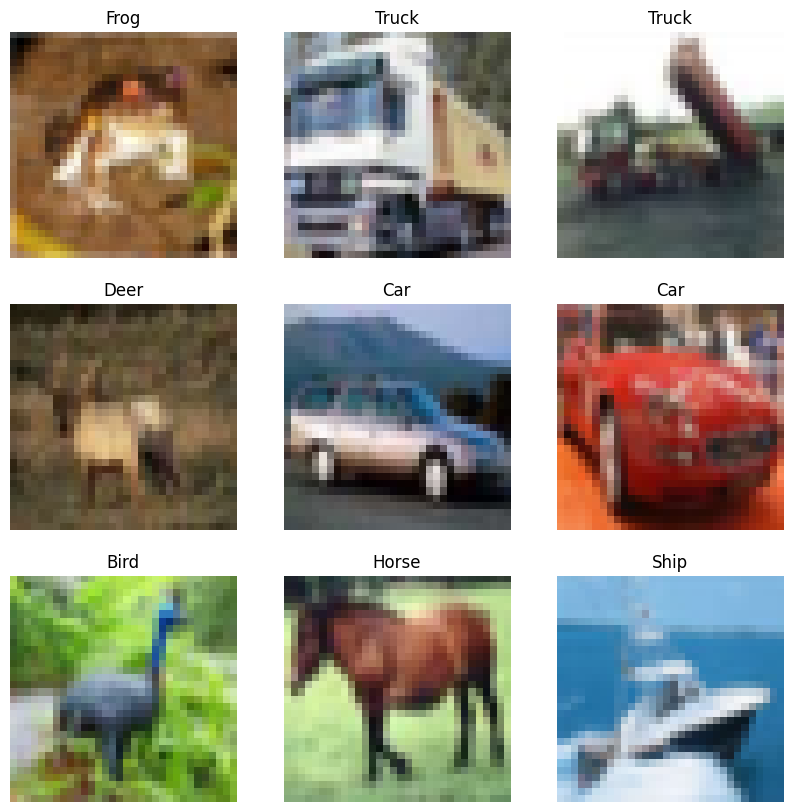

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.4623 - loss: 1.4888 - val_accuracy: 0.5537 - val_loss: 1.2442
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 35ms/step - accuracy: 0.5958 - loss: 1.1494 - val_accuracy: 0.6172 - val_loss: 1.0757
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6425 - loss: 1.0212 - val_accuracy: 0.6359 - val_loss: 1.0409
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6759 - loss: 0.9333 - val_accuracy: 0.6518 - val_loss: 0.9951
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 37ms/step - accuracy: 0.7029 - loss: 0.8623 - val_accuracy: 0.6608 - val_loss: 0.9727
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7191 - loss: 0.8023 - val_accuracy: 0.6785 - val_loss: 0.9316
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7400 - loss: 0.7455 - val_accuracy: 0.6809 - val_loss: 0.9333
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7582 -

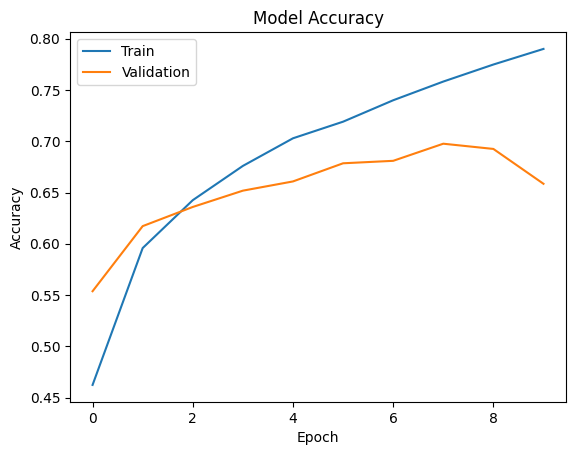

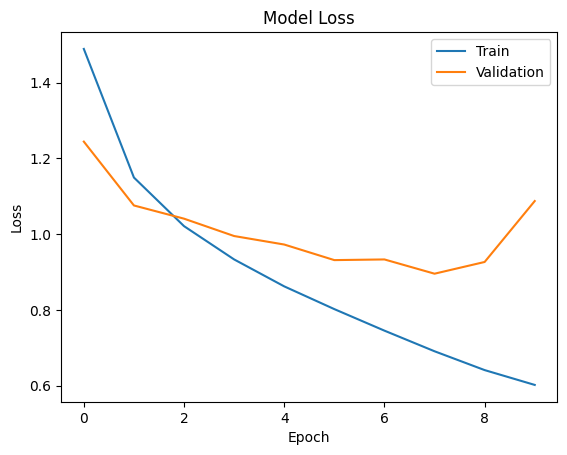

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


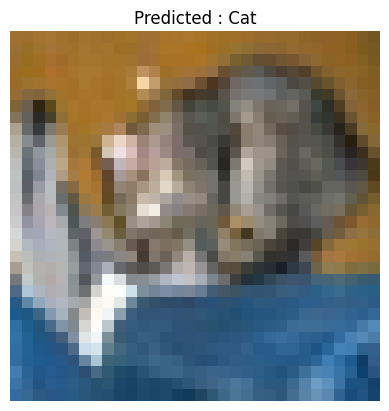

CNN Model Saved Successfully


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
\

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0

classes = ['Airplane','Car','Bird','Cat','Deer',
           'Dog','Frog','Horse','Ship','Truck']


plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_train[i])

    plt.title(classes[y_train[i][0]])

    plt.axis('off')

plt.show()

cnn = Sequential()

cnn.add(
    Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=(32,32,3)
    )
)

# First Pooling Layer
cnn.add(
    MaxPooling2D(
        pool_size=2,
        strides=2
    )
)

cnn.add(
    Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D(
        pool_size=2,
        strides=2
    )
)
cnn.add(Flatten())

cnn.add(
    Dense(
        units=128,
        activation='relu'
    )
)

cnn.add(
    Dense(
        units=10,
        activation='softmax'
    )
)

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test,y_test)
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

prediction = cnn.predict(x_test)

predicted_class = np.argmax(prediction[0])

plt.imshow(x_test[0])

plt.title("Predicted : " + classes[predicted_class])

plt.axis('off')

plt.show()

cnn.save("cnn_model.h5")

print("CNN Model Saved Successfully")